In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!pip freeze > requirements.txt
!pip install virtualenv
#!virtualenv /content/drive/MyDrive/ics635_env
#!source /content/drive/MyDrive/ics635_env/bin/activate; pip install -r requirements.txt; pip install numpy; !pip install pandas; pip install opencv-python; pip install supervision; pip install jupyter_bbox_widget
#!source /content/drive/MyDrive/ics635_env/bin/activate; pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'
#!source /content/drive/MyDrive/ics635_env/bin/activate; pip install dask

#%cd /content/drive/MyDrive/ics635_env/
#!git clone https://github.com/IDEA-Research/GroundingDINO.git
#%cd GroundingDINO/
#!source /content/drive/MyDrive/ics635_env/bin/activate; pip install -e .

#!mkdir weights
#%cd weights
#!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth
#%cd /content

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/pip/_vendor/pkg_resources/__init__.py", line 3108, in _dep_map
    return self.__dep_map
  File "/usr/local/lib/python3.10/dist-packages/pip/_vendor/pkg_resources/__init__.py", line 2901, in __getattr__
    raise AttributeError(attr)
AttributeError: _DistInfoDistribution__dep_map

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/base_command.py", line 169, in exc_logging_wrapper
    status = run_func(*args)
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/req_command.py", line 242, in wrapper
    return func(self, options, args)
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/commands/install.py", line 441, in run
    conflicts = self._determine_conflicts(to_install)
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/commands/install.py", line 

In [ ]:
!export CUDA_HOME=/usr/local/cuda/bin/nvcc

In [ ]:
import os
import sys
import multiprocessing

sys.path.append("/content/drive/MyDrive/ics635_env/lib/python3.10/site-packages")

import PIL
from PIL import Image

import dask
import dask.dataframe as dd

import multiprocessing

import pandas as pd
import torch

import cv2
from google.colab.patches import cv2_imshow

import numpy as np
import multiprocessing
import concurrent.futures
import shutil
from skimage.io import imread
import matplotlib.pyplot as plt
import tensorflow as tf

data_dir = "/content/drive/MyDrive/ICS635_FINAL_DATA"

/content/drive/MyDrive/ics635_env/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py ; exist: True
/content/drive/MyDrive/ics635_env/GroundingDINO/weights/groundingdino_swint_ogc.pth ; exist: True
/content/drive/MyDrive/ics635_env/GroundingDINO
/content


In [ ]:

df_native = pd.read_csv(os.path.join(data_dir, 'df_native.csv'))
df_native['image_path'] = df_native['image_path'].apply(lambda x: os.path.join(data_dir, "images_native_want", os.path.basename(x)))
df_introduced = pd.read_csv(os.path.join(data_dir, 'df_introduced.csv'))
df_introduced['image_path'] = df_introduced['image_path'].apply(lambda x: os.path.join(data_dir, "images_introduced_want", os.path.basename(x)))

df_native['origin'] = 'native'
df_introduced['origin'] = 'introduced'
df = pd.concat([df_native, df_introduced])
df.reset_index(drop=True, inplace=True)

example_img_path = os.path.join(data_dir, "images_native_want", "214785538.jpg")


In [ ]:
# Get the number of CPU cores
#num_cores = multiprocessing.cpu_count()
#num_cores = max(1, num_cores - 2)  # One less than the number of cores
from dask.distributed import Client, LocalCluster
#cluster = LocalCluster(num_cores)
client = Client(n_workers=14)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36399
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34651'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45277'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41871'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43377'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:42349'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38193'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33817'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41079'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45667'
INFO:distributed.nanny:      

In [ ]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Status: closed,Using processes: True
Comm: tcp://127.0.0.1:36399,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: 1 hour ago,Total memory: 0 B


In [ ]:
def print_img(img):
  plt.imshow(img)
  plt.show()

In [ ]:
ddf = dd.from_pandas(df, npartitions=14)

In [ ]:
#df['image'] = ddf['image_path'].apply(imread, meta=('img_loaded', np.uint8)).compute()
def open_image(image_path, width=200, height=200):
    image = np.asarray(Image.open(image_path).resize((width, height)))
    return image
df['image'] = ddf['image_path'].apply(open_image, meta=('image', np.uint8)).compute()

In [ ]:
client.close()

NameError: name 'cluster' is not defined

In [ ]:
#filtered_images = df[df['image'].apply(lambda x: x.shape) != (200, 200, 3)]

def convert_to_rgb(img):
    # If image has shape (200, 200, 4), discard the alpha channel
    if len(img.shape) == 3 and img.shape[2] == 4:
        return img[:, :, :3]
    # If image has shape (200, 200, 3), return as is
    elif len(img.shape) == 3 and img.shape[2] == 3:
        return img
    # If image has shape (200, 200), convert grayscale to RGB by duplicating the single channel
    elif len(img.shape) == 2:
        return np.stack((img,) * 3, axis=-1)
    else:
        # Handle other cases or raise an error if needed
        raise ValueError("Invalid image shape")

# Apply the conversion function to each image in the 'image' column
df['image'] = df['image'].apply(convert_to_rgb)
images_array = np.stack(df['image'].to_numpy())

In [ ]:
"""SAVE"""
!mkdir /content/drive/MyDrive/ICS635_FINAL_DATA/final

df.to_csv(data_dir + '/final/dataframe.csv', index=False)
np.save(data_dir + '/final/images_array.npy', images_array)
np.save(data_dir + '/final/labels_origin.npy', df['origin'].values)
np.save(data_dir + '/final/labels_species.npy', df['scientific_name'].values)

In [ ]:
"""filtered_images = df[df['image'].apply(lambda x: x.shape) != (200, 200, 3)]
filtered_images['image_shape'] = df['image'].apply(lambda x: x.shape)
filtered_images['image_shape'].unique()
img = (filtered_images[filtered_images['image_shape'] == (200,200)]['image'].iloc[0])
img_rgb = np.stack((img,) * 3, axis=-1)
print_img(img_rgb)
"""


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# LOAD IN SAVED DATA

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

data_dir = "/content/drive/MyDrive/ICS635_FINAL_DATA"
images_array = np.load(data_dir + '/final/images_array.npy', allow_pickle=True)
labels_origin = np.load(data_dir + '/final/labels_origin.npy', allow_pickle=True)
labels_species = np.load(data_dir + '/final/labels_species.npy', allow_pickle=True)

images_array = (images_array.astype(np.float16)) / 255.0

label_encoder = LabelEncoder()

labels_origin = label_encoder.fit_transform(labels_origin)

labels_species = label_encoder.fit_transform(labels_species)
num_classes = len(np.unique(labels_species))
labels_species = to_categorical(labels_species, num_classes)


# ORIGIN CLASSIFICATION

In [ ]:
#import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tensorflow.keras import applications
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(images_array, labels_origin, test_size=0.2, random_state=42)

In [ ]:
count_ones = np.count_nonzero(y_train)
print(y_train.shape)
print(count_ones)
y_train[:100]

(16000,)
7981


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1])

In [ ]:
def plot_roc(mdl, X_test, y_test, model_name, save_to=None):
  # Obtain predicted probabilities for the positive class (class 1)
  y_pred_prob = mdl.predict(X_test)

  # Compute ROC curve and AUC
  fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
  roc_auc = auc(fpr, tpr)

  # Plot ROC curve
  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'{model_name} ROC Curve')
  plt.legend(loc='lower right')
  plt.show()
  if save_to:
    plt.savefig(save_to)

# Custom CNN

In [ ]:
# Define the TensorFlow model
input_shape = (200, 200, 3)

def create_tf_model(input_shape):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model


tf_model = create_tf_model(input_shape)
tf_model.compile(optimizer=Adam(learning_rate=0.01),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Load the saved model
#tf_model = load_model(data_dir + '/models/my_model.keras')

In [ ]:
tf_model.fit(x=X_train,
             y=y_train,
             epochs=40,
             batch_size=50,
             validation_split=0.2,
             verbose=2,
             callbacks=[EarlyStopping(monitor="val_loss", patience=2)]
             )

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

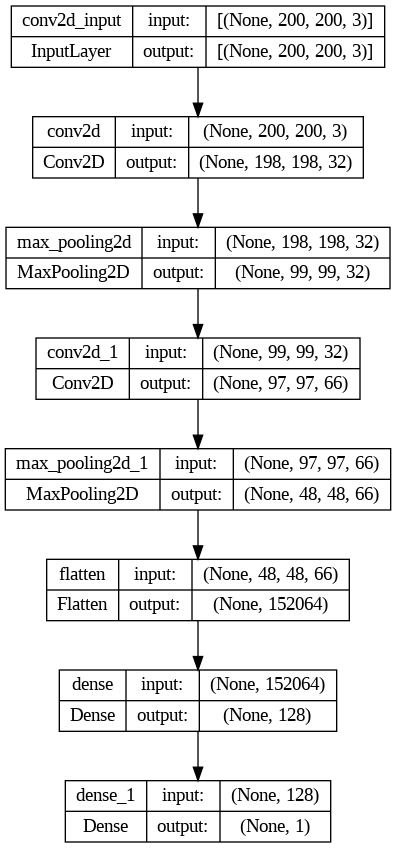

In [ ]:
plot_model(tf_model, to_file=data_dir + '/models/origin/model_architecture.png', show_shapes=True)

125/125 [==============================] - 2s 11ms/step


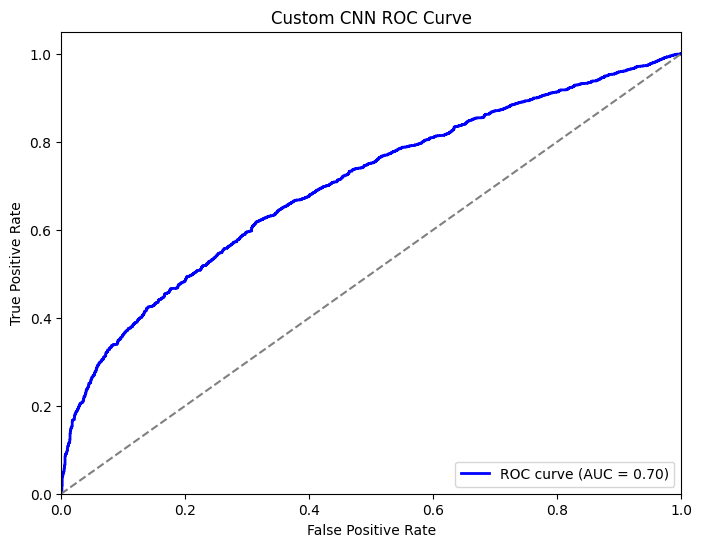

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_roc(tf_model, X_test, y_test, "Custom CNN", data_dir + "/models/origin/custom_cnn_roc.png")

In [ ]:
tf_model.save(data_dir + '/models/my_model.keras')

# inceptionv3

In [ ]:
inception_model = applications.InceptionV3(
            weights='imagenet',
            include_top=False,
            input_shape=(200, 200, 3))


87910968/87910968 [==============================] - 1s 0us/step


In [ ]:
for layer in inception_model.layers:
    layer.trainable = False

mdl = Sequential([
        inception_model,
        GlobalAveragePooling2D(),
        Dense(1024, activation='relu'),
        Dense(1, activation='sigmoid')])

mdl.compile(optimizer=Adam(learning_rate=0.01),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])


mdl.fit(x=X_train,
        y=y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=2,
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
        )


Epoch 1/10
500/500 [==============================] - 28s 38ms/step - loss: 0.3727 - accuracy: 0.8320 - val_loss: 0.3065 - val_accuracy: 0.8620
Epoch 2/10
500/500 [==============================] - 13s 26ms/step - loss: 0.2881 - accuracy: 0.8752 - val_loss: 0.2932 - val_accuracy: 0.8652
Epoch 3/10
500/500 [==============================] - 13s 27ms/step - loss: 0.2463 - accuracy: 0.8964 - val_loss: 0.2948 - val_accuracy: 0.8677
Epoch 4/10
500/500 [==============================] - 13s 26ms/step - loss: 0.2063 - accuracy: 0.9163 - val_loss: 0.2820 - val_accuracy: 0.8788
Epoch 5/10
500/500 [==============================] - 13s 26ms/step - loss: 0.1721 - accuracy: 0.9320 - val_loss: 0.2835 - val_accuracy: 0.8795
Epoch 6/10
500/500 [==============================] - 13s 26ms/step - loss: 0.1360 - accuracy: 0.9520 - val_loss: 0.3169 - val_accuracy: 0.8652
Epoch 7/10
500/500 [==============================] - 13s 27ms/step - loss: 0.1101 - accuracy: 0.9621 - val_loss: 0.3040 - val_accuracy:

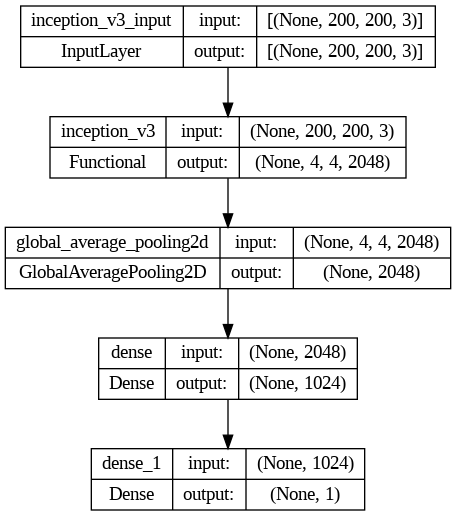

In [ ]:
plot_model(mdl, to_file=data_dir + '/models/inceptionv3_architecture.png', show_shapes=True)

125/125 [==============================] - 3s 20ms/step


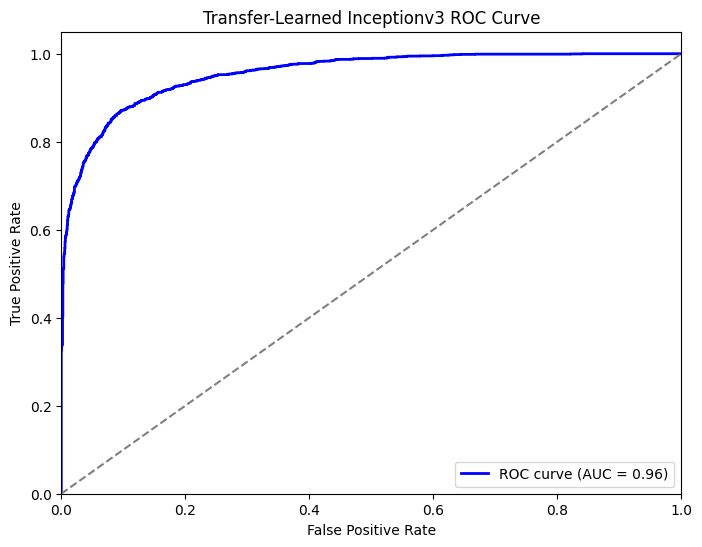

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_roc(mdl, X_test, y_test, "Transfer-Learned Inceptionv3", data_dir + "/models/inception_roc.png")

In [ ]:
mdl.save(data_dir + '/models/transfer_learned.keras')

In [ ]:

mdl.fit(x=X_train,
        y=y_train,
        epochs=40,
        batch_size=32,
        validation_split=0.2,
        verbose=2,
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
        )

Epoch 1/40
400/400 - 13s - loss: 0.0298 - accuracy: 0.9961 - val_loss: 0.0337 - val_accuracy: 0.9950 - 13s/epoch - 33ms/step
Epoch 2/40
400/400 - 10s - loss: 0.0204 - accuracy: 0.9986 - val_loss: 0.0974 - val_accuracy: 0.9622 - 10s/epoch - 26ms/step
Epoch 3/40
400/400 - 10s - loss: 0.0186 - accuracy: 0.9983 - val_loss: 0.0338 - val_accuracy: 0.9928 - 10s/epoch - 25ms/step
Epoch 4/40
400/400 - 10s - loss: 0.0099 - accuracy: 0.9998 - val_loss: 0.0319 - val_accuracy: 0.9928 - 10s/epoch - 26ms/step
Epoch 5/40
400/400 - 10s - loss: 0.0059 - accuracy: 1.0000 - val_loss: 0.0304 - val_accuracy: 0.9912 - 10s/epoch - 26ms/step
Epoch 6/40
400/400 - 10s - loss: 0.0044 - accuracy: 1.0000 - val_loss: 0.0390 - val_accuracy: 0.9853 - 10s/epoch - 25ms/step
Epoch 7/40
400/400 - 10s - loss: 0.0034 - accuracy: 1.0000 - val_loss: 0.0368 - val_accuracy: 0.9869 - 10s/epoch - 25ms/step
Epoch 8/40
400/400 - 10s - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.0393 - val_accuracy: 0.9850 - 10s/epoch - 25ms/step


125/125 [==============================] - 3s 20ms/step


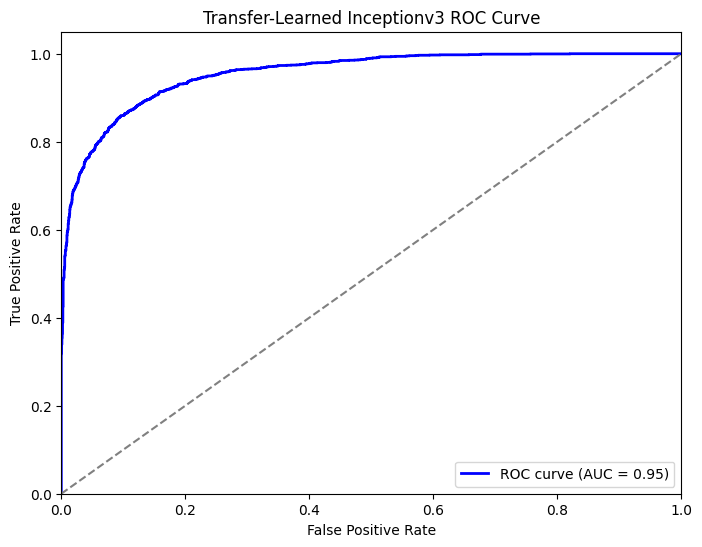

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_roc(mdl, X_test, y_test, "Transfer-Learned Inceptionv3", data_dir + "/models/inception_roc.png")

# VGG19

In [ ]:
vgg = applications.VGG19(
            weights='imagenet',
            include_top=False,
            input_shape=(200, 200, 3))

for layer in vgg.layers:
    layer.trainable = False

vgg_model = Sequential([
        vgg,
        GlobalAveragePooling2D(),
        Dense(1024, activation='relu'),
        Dense(1, activation='sigmoid')])

vgg_model.compile(optimizer=Adam(learning_rate=0.01),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])


vgg_model.fit(x=X_train,
        y=y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=2,
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
        )


80134624/80134624 [==============================] - 5s 0us/step
Epoch 1/100
400/400 - 19s - loss: 0.6243 - accuracy: 0.6831 - val_loss: 0.5494 - val_accuracy: 0.7172 - 19s/epoch - 47ms/step
Epoch 2/100
400/400 - 10s - loss: 0.5343 - accuracy: 0.7231 - val_loss: 0.5182 - val_accuracy: 0.7447 - 10s/epoch - 26ms/step
Epoch 3/100
400/400 - 10s - loss: 0.5116 - accuracy: 0.7418 - val_loss: 0.5285 - val_accuracy: 0.7294 - 10s/epoch - 25ms/step
Epoch 4/100
400/400 - 10s - loss: 0.4960 - accuracy: 0.7556 - val_loss: 0.5139 - val_accuracy: 0.7459 - 10s/epoch - 26ms/step
Epoch 5/100
400/400 - 10s - loss: 0.4906 - accuracy: 0.7575 - val_loss: 0.5739 - val_accuracy: 0.7094 - 10s/epoch - 25ms/step
Epoch 6/100
400/400 - 10s - loss: 0.4866 - accuracy: 0.7595 - val_loss: 0.5050 - val_accuracy: 0.7559 - 10s/epoch - 26ms/step
Epoch 7/100
400/400 - 10s - loss: 0.4774 - accuracy: 0.7685 - val_loss: 0.4980 - val_accuracy: 0.7625 - 10s/epoch - 26ms/step
Epoch 8/100
400/400 - 10s - loss: 0.4693 - accuracy: 

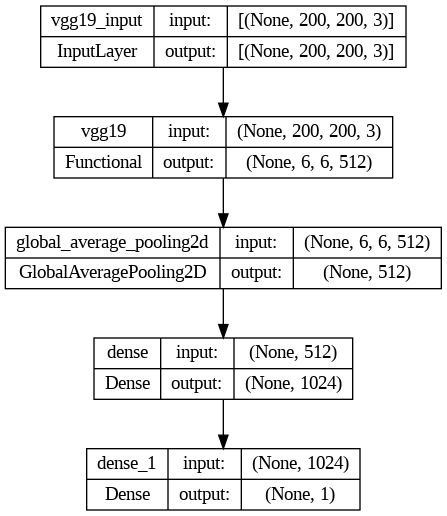

In [ ]:
vgg_model.save(data_dir + '/models/origin/vgg19.keras')
plot_model(vgg_model, to_file=data_dir + '/models/origin/vgg_architecture.png', show_shapes=True)

125/125 [==============================] - 3s 20ms/step


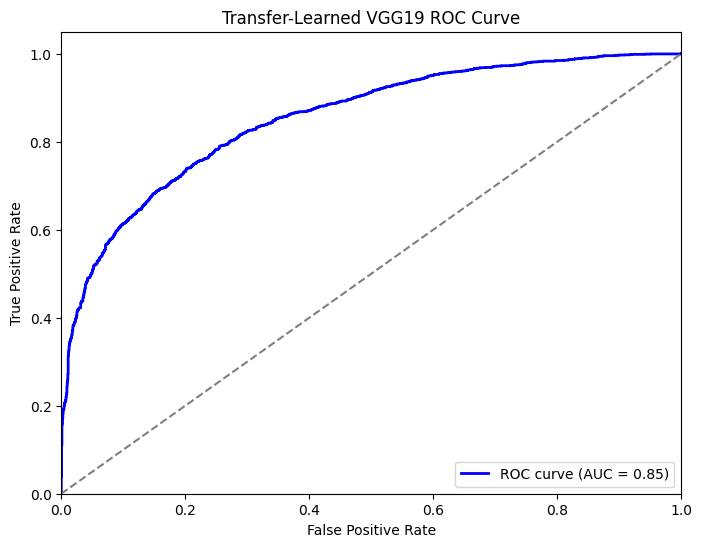

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_roc(vgg_model, X_test, y_test, "Transfer-Learned VGG19", data_dir + "/models/origin/vgg19_roc.png")

# resnet


In [ ]:
resnet = applications.ResNet50V2(
            weights='imagenet',
            include_top=False,
            input_shape=(200, 200, 3))

for layer in resnet.layers:
    layer.trainable = False

resnet_model = Sequential([
        resnet,
        GlobalAveragePooling2D(),
        Dense(1024, activation='relu'),
        Dense(1, activation='sigmoid')])

resnet_model.compile(optimizer=Adam(learning_rate=0.01),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])


resnet_model.fit(x=X_train,
        y=y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=2,
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
        )


94668760/94668760 [==============================] - 5s 0us/step
Epoch 1/100
400/400 - 18s - loss: 0.5279 - accuracy: 0.8288 - val_loss: 0.4690 - val_accuracy: 0.8084 - 18s/epoch - 44ms/step
Epoch 2/100
400/400 - 10s - loss: 0.3133 - accuracy: 0.8631 - val_loss: 0.3347 - val_accuracy: 0.8522 - 10s/epoch - 24ms/step
Epoch 3/100
400/400 - 10s - loss: 0.2741 - accuracy: 0.8812 - val_loss: 0.3431 - val_accuracy: 0.8547 - 10s/epoch - 24ms/step
Epoch 4/100
400/400 - 10s - loss: 0.2416 - accuracy: 0.8972 - val_loss: 0.4281 - val_accuracy: 0.8447 - 10s/epoch - 24ms/step


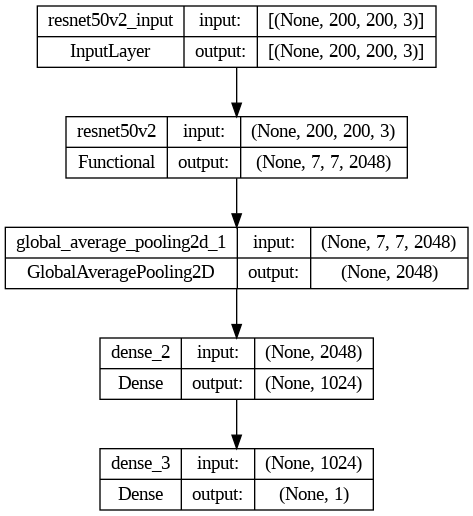

In [ ]:
resnet_model.save(data_dir + '/models/origin/resnset.keras')
plot_model(resnet_model, to_file=data_dir + '/models/origin/resnset_architecture.png', show_shapes=True)

125/125 [==============================] - 3s 19ms/step


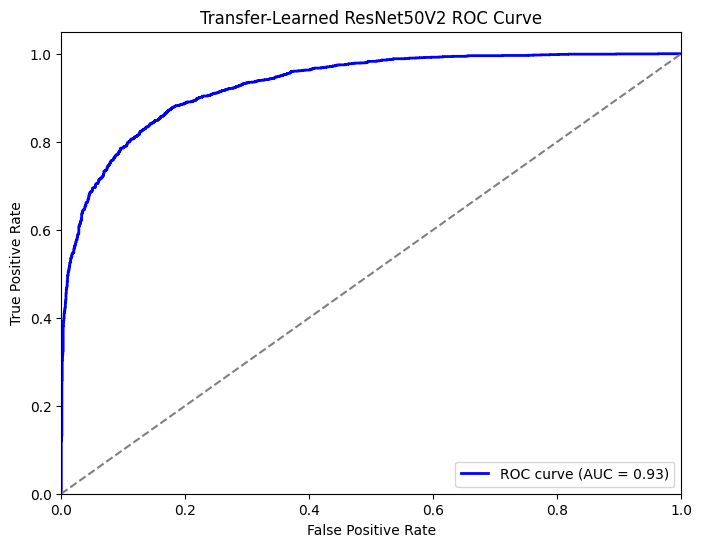

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_roc(resnet_model, X_test, y_test, "Transfer-Learned ResNet50V2", data_dir + "/models/origin/resnet_roc.png")

# SPECIES CLASSIFICATION

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(images_array, labels_species, test_size=0.2, random_state=42)

# custom cnn

In [ ]:
# Define the TensorFlow model
input_shape = (200, 200, 3)

def custom_species_classifier(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    return model


custom_species_cnn = custom_species_classifier(input_shape, num_classes)
custom_species_cnn.compile(optimizer=Adam(learning_rate=0.01),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Load the saved model
#tf_model = load_model(data_dir + '/models/my_model.keras')

In [ ]:
custom_species_cnn.fit(x=X_train,
             y=y_train,
             epochs=40,
             batch_size=50,
             validation_split=0.2,
             verbose=2,
             callbacks=[EarlyStopping(monitor="val_loss", patience=2)]
             )

#6

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

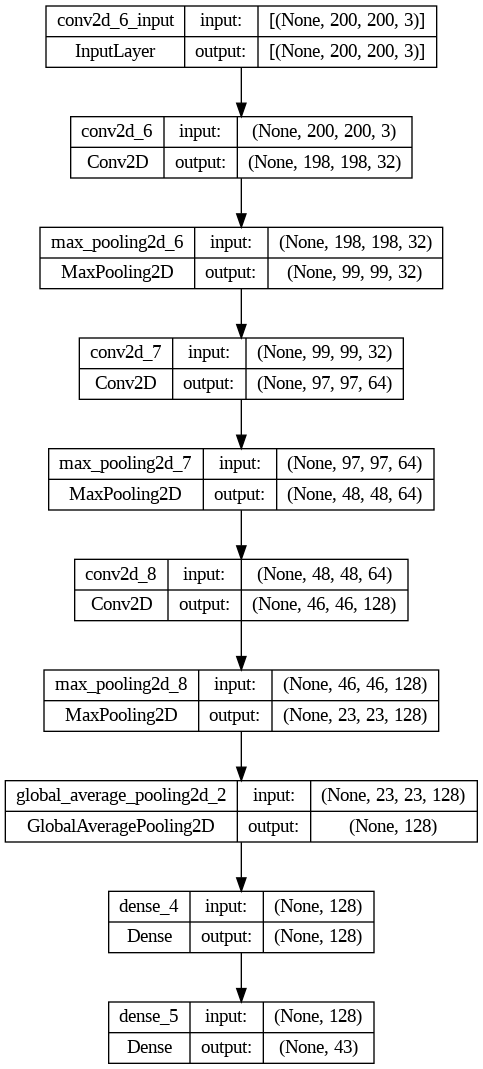

In [ ]:
plot_model(custom_species_cnn, to_file=data_dir + '/models/species/custom_cnn_model_architecture.png', show_shapes=True)

In [ ]:
top_k_accuracy(custom_species_cnn, X_test, y_test, k=5)

125/125 [==============================] - 1s 6ms/step
orig:  [22 22 22 ... 22 22 22]
pred:  [22 22 22 ... 27 22 22]
true:  [28 19 22 ... 27 12 16]
(4000,)
(4000,)
[22]
[15 22 27 34 35]
Precision per class: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         1.         0.         0.
 0.         0.         0.         0.         0.03931275 0.
 0.         0.         0.         1.         0.         0.
 0.         0.         0.         0.         1.         1.
 0.         0.         0.         0.         0.         0.
 0.        ]
Recall per class: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
F1 Score per class: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         1.         0.         0.
 0.         0.      

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_multiclass(model, X_test, y_test):
  y_pred = model.predict(X_test)
  y_pred_labels = np.argmax(y_pred, axis=1)
  y_test_labels = np.argmax(y_test, axis=1)

  # Assuming y_true and y_pred are your true labels and predicted labels respectively
  # y_true and y_pred should be arrays of the same shape containing integer labels

  # Calculate precision, recall, and F1 score for each class
  precision_per_class = precision_score(y_test_labels, y_pred_labels, average=None)
  recall_per_class = recall_score(y_test_labels, y_pred_labels, average=None)
  f1_per_class = f1_score(y_test_labels, y_pred_labels, average=None)

  # Calculate macro-average precision, recall, and F1 score
  macro_precision = precision_score(y_test_labels, y_pred_labels, average='macro')
  macro_recall = recall_score(y_test_labels, y_pred_labels, average='macro')
  macro_f1 = f1_score(y_test_labels, y_pred_labels, average='macro')

  print("Precision per class:", precision_per_class)
  print("Recall per class:", recall_per_class)
  print("F1 Score per class:", f1_per_class)
  print("Macro-average Precision:", macro_precision)
  print("Macro-average Recall:", macro_recall)
  print("Macro-average F1 Score:", macro_f1)

evaluate_multiclass(custom_species_cnn, X_test, y_test)

125/125 [==============================] - 1s 6ms/step
Precision per class: [0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.03375 0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]
Recall per class: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
F1 Score per class: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.06529625 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.        

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Inceptionv3

In [ ]:
inception_model = applications.InceptionV3(
            weights='imagenet',
            include_top=False,
            input_shape=(200, 200, 3))

for layer in inception_model.layers:
    layer.trainable = False

mdl = Sequential([
        inception_model,
        GlobalAveragePooling2D(),
        Dense(1024, activation='relu'),
        Dense(num_classes, activation='softmax')])

mdl.compile(optimizer=Adam(learning_rate=0.01),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])


mdl.fit(x=X_train,
        y=y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=2,
        #callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
        )


Epoch 1/100
400/400 - 15s - loss: 4.2961 - accuracy: 0.2481 - val_loss: 2.5720 - val_accuracy: 0.2875 - 15s/epoch - 38ms/step
Epoch 2/100
400/400 - 7s - loss: 2.4121 - accuracy: 0.3192 - val_loss: 2.5030 - val_accuracy: 0.3419 - 7s/epoch - 18ms/step
Epoch 3/100
400/400 - 7s - loss: 2.2876 - accuracy: 0.3538 - val_loss: 2.5210 - val_accuracy: 0.3047 - 7s/epoch - 18ms/step
Epoch 4/100
400/400 - 7s - loss: 2.2406 - accuracy: 0.3635 - val_loss: 2.4028 - val_accuracy: 0.3522 - 7s/epoch - 18ms/step
Epoch 5/100
400/400 - 7s - loss: 2.1345 - accuracy: 0.3919 - val_loss: 2.5615 - val_accuracy: 0.3475 - 7s/epoch - 18ms/step
Epoch 6/100
400/400 - 7s - loss: 2.1215 - accuracy: 0.3971 - val_loss: 2.4441 - val_accuracy: 0.3694 - 7s/epoch - 18ms/step
Epoch 7/100
400/400 - 7s - loss: 2.0369 - accuracy: 0.4084 - val_loss: 2.4884 - val_accuracy: 0.3581 - 7s/epoch - 18ms/step
Epoch 8/100
400/400 - 7s - loss: 2.0300 - accuracy: 0.4198 - val_loss: 2.5432 - val_accuracy: 0.3628 - 7s/epoch - 18ms/step
Epoch 

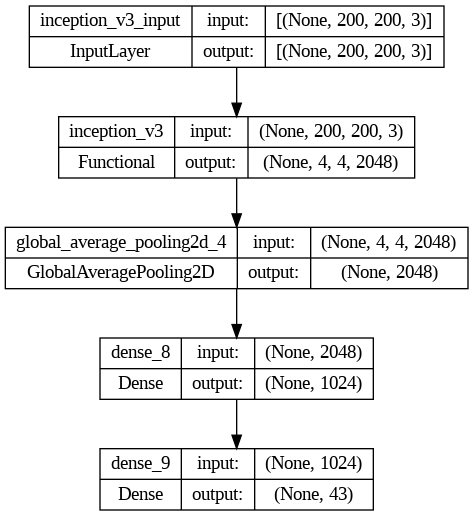

In [ ]:
plot_model(mdl, to_file=data_dir + '/models/species/inceptionv3_architecture.png', show_shapes=True)

In [ ]:
mdl.save(data_dir + '/models/species/inceptionv3.keras')


In [ ]:
top_k_eval(mdl, X_test, y_test, k=1)

125/125 [==============================] - 2s 14ms/step
Precision per class: [0.09859155 0.5        0.76       0.70454545 0.63243243 0.86486486
 0.35897436 0.16949153 0.10810811 0.25490196 0.75       0.
 0.52727273 0.08       0.70833333 0.77372263 0.         0.38194444
 0.17647059 0.52       1.         0.7734375  0.19194313 0.
 0.         0.         0.63265306 0.68539326 0.44262295 0.0952381
 0.06906077 0.         0.         0.54545455 0.15568862 0.75
 0.         0.90625    0.43421053 0.09345794 0.28957529 0.64754098
 0.12019231]
Recall per class: [0.08235294 0.04       0.32478632 0.55855856 0.72670807 0.36781609
 0.28       0.10416667 0.04938272 0.16049383 0.22826087 0.
 0.2815534  0.04651163 0.75221239 0.8030303  0.         0.6547619
 0.28378378 0.33333333 0.1954023  0.65562914 0.6        0.
 0.         0.         0.37349398 0.42657343 0.31764706 0.02631579
 0.64102564 0.         0.         0.37974684 0.17808219 0.53793103
 0.         0.3625     0.46478873 0.13157895 0.55147059 0.530

In [ ]:
def top_k_eval(model, X_test, y_test, k=1):
    y_pred_prob = model.predict(X_test)
    y_pred_labels_orig = np.argmax(y_pred_prob, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
    # Get the top-k predicted classes for each sample
    top_k_classes = np.argsort(y_pred_prob, axis=1)[:, -k:]

    # Check if the true class is among the top-k predicted classes
    y_pred_labels = np.array([true_class if true_class in top_k else y_pred_label_orig for true_class, top_k, y_pred_label_orig in zip(y_test_labels, top_k_classes, y_pred_labels_orig)])

    # Calculate precision, recall, and F1 score for each class
    precision_per_class = precision_score(y_test_labels, y_pred_labels, average=None)
    recall_per_class = recall_score(y_test_labels, y_pred_labels, average=None)
    f1_per_class = f1_score(y_test_labels, y_pred_labels, average=None)

    # Calculate macro-average precision, recall, and F1 score
    macro_precision = precision_score(y_test_labels, y_pred_labels, average='macro')
    macro_recall = recall_score(y_test_labels, y_pred_labels, average='macro')
    macro_f1 = f1_score(y_test_labels, y_pred_labels, average='macro')

    print("Precision per class:", precision_per_class)
    print("Recall per class:", recall_per_class)
    print("F1 Score per class:", f1_per_class)
    print("Macro-average Precision:", macro_precision)
    print("Macro-average Recall:", macro_recall)
    print("Macro-average F1 Score:", macro_f1)

#top_k_eval(mdl, X_test, y_test, k=5)


# GROUNDING DINO

In [ ]:
import sys
import os

sys.path.append("/content/drive/MyDrive/ics635_env/lib/python3.10/site-packages")

from segment_anything import SamPredictor, sam_model_registry, SamAutomaticMaskGenerator

CONFIG_PATH = os.path.join("/content/drive/MyDrive/ics635_env", "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py")
print(CONFIG_PATH, "; exist:", os.path.isfile(CONFIG_PATH))

WEIGHTS_PATH = os.path.join("/content/drive/MyDrive/ics635_env", "GroundingDINO/weights/groundingdino_swint_ogc.pth")
print(WEIGHTS_PATH, "; exist:", os.path.isfile(WEIGHTS_PATH))

%cd /content/drive/MyDrive/ics635_env/GroundingDINO/
from groundingdino.util.inference import load_model, load_image, predict, annotate
%cd /content

import supervision as sv


/content/drive/MyDrive/ics635_env/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py ; exist: True
/content/drive/MyDrive/ics635_env/GroundingDINO/weights/groundingdino_swint_ogc.pth ; exist: True
/content/drive/MyDrive/ics635_env/GroundingDINO
/content


In [ ]:
sam = sam_model_registry["vit_l"](checkpoint="/content/drive/MyDrive/ICS635_FINAL_DATA/sam_vit_l_0b3195.pth")

mask_generator = SamAutomaticMaskGenerator(sam)
mask_predictor = SamPredictor(sam)

img_rgb = cv2.imread(example_img_path)
# image_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
sam_result = mask_generator.generate(img_rgb)

mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
detections = sv.Detections.from_sam(sam_result=sam_result)
annotated_image = mask_annotator.annotate(scene=img_rgb.copy(), detections=detections)
sv.plot_images_grid(
    images=[img_rgb, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)


In [ ]:
def get_box_coordinates(img):
  """
  use Grounded Dino to get a predicted box of the bird in the image, then return
  the coordinates of the box if it exists
  """
  x1 = None
  y1 = None
  x2 = None
  y2 = None

  TEXT_PROMPT = "bird"
  BOX_TRESHOLD = 0.35
  TEXT_TRESHOLD = 0.25

  image_source, image = load_image(img)

  H,W, _ = image_source.shape

  boxes, logits, phrases = predict(
      model=dino_model,
      image=image,
      caption=TEXT_PROMPT,
      box_threshold=BOX_TRESHOLD,
      text_threshold=TEXT_TRESHOLD
  )

  #annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
  #%matplotlib inline
  #sv.plot_image(annotated_frame, (16, 16))
  for box in boxes:
      x_center = box[0].item()
      y_center = box[1].item()
      width = box[2].item()
      height = box[3].item()

      # Convert normalized coordinates [0, 1] back to pixel values.
      x_center = x_center * W
      y_center = y_center * H
      width = width * W
      height = height * H

      # Calculate the top-left (x1, y1) and bottom-right (x2, y2) coordinates of the box.
      x1 = int(x_center - (width / 2))
      y1 = int(y_center - (height / 2))
      x2 = int(x_center + (width / 2))
      y2 = int(y_center + (height / 2))


  """
  image = cv2.imread(img)
  color = (0, 0, 255)
  thickness = 2
  cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)
  cv2.imshow(image)
  """

  return x1, y1, x2, y2


def process_image(img_path):
    try:
        # Process the image and get box coordinates
        x1, y1, x2, y2 = get_box_coordinates(img_path)
        #df.loc[df['image_path'] == img_path, ['x1', 'x2', 'x3', 'x4']] = [x1, y1, x2, y2]
        return img_path, x1, y1, x2, y2
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        return None, None, None, None, None


def process_images_concurrently(image_files):
    results = []
    with concurrent.futures.ThreadPoolExecutor() as executor:
        # Submit tasks for each image processing
        futures = [executor.submit(process_image, img_path) for img_path in image_files]
        # Retrieve results as they become available
        for future in concurrent.futures.as_completed(futures):
            results.append(future.result())
    return results

"""
image_files = [os.path.join("/content/images_native_want", filename) for filename in os.listdir("/content/images_native_want")]

results = process_images_concurrently(image_files)
df_results = pd.DataFrame(results, columns=['img_path', 'x1', 'y1', 'x2', 'y2'])
print(df_results.head())
#df_native = pd.merge(df_native, df_results, on='img_path', how='left')
"""

image_files = [os.path.join(data_dir, "images_native_want", filename) for filename in os.listdir(data_dir + "/images_native_want")]
results = process_images_concurrently(image_files)
df_results = pd.DataFrame(results, columns=['img_path', 'x1', 'y1', 'x2', 'y2'])
print(df_results.head())
df_native = pd.merge(df_native, df_results, on='img_path', how='left')

"""
for img_path in image_files:
    x1, y1, x2, y2 = process_image(img_path)


with concurrent.futures.ThreadPoolExecutor() as executor:
    # Submit the process_image function to the executor for each image
    futures = [executor.submit(process_image, img_path) for img_path in image_files]

    # Iterate over the completed futures to get results
    for future in concurrent.futures.as_completed(futures):
        result = future.result()
"""
#x1, y1, x2, y2 = get_box_coordinates(example_img_path)



/content/drive/MyDrive/ICS635_FINAL_DATA/images_native_want/195425405.jpg
Error processing image /content/drive/MyDrive/ICS635_FINAL_DATA/images_native_want/196608293.jpg: The size of tensor a (17821) must match the size of tensor b (17769) at non-singleton dimension 1
Error processing image /content/drive/MyDrive/ICS635_FINAL_DATA/images_native_want/196614398.jpg: The size of tensor a (17821) must match the size of tensor b (17769) at non-singleton dimension 1
Error processing image /content/drive/MyDrive/ICS635_FINAL_DATA/images_native_want/196608693.jpg: The size of tensor a (17821) must match the size of tensor b (17769) at non-singleton dimension 1
Error processing image /content/drive/MyDrive/ICS635_FINAL_DATA/images_native_want/196628599.jpg: The size of tensor a (17821) must match the size of tensor b (17769) at non-singleton dimension 1
Error processing image /content/drive/MyDrive/ICS635_FINAL_DATA/images_native_want/196720904.jpg: The size of tensor a (17821) must match the 

RuntimeError: The size of tensor a (17821) must match the size of tensor b (17769) at non-singleton dimension 1

In [ ]:
dino_model = load_model(CONFIG_PATH, WEIGHTS_PATH)

final text_encoder_type: bert-base-uncased


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
#from re import M
def segment_given_box(img_path, mask_predictor, x1, y1, x2, y2):
  box = np.array([x1, y1, x2, y2])

  image_bgr = cv2.imread(img_path)
  image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

  mask_predictor.set_image(image_rgb)
  masks, scores, logits = mask_predictor.predict(
      box=box,
      multimask_output=True
  )

  box_annotator = sv.BoxAnnotator(color=sv.Color.red())
  mask_annotator = sv.MaskAnnotator(color=sv.Color.red(), color_lookup=sv.ColorLookup.INDEX)

  detections = sv.Detections(
      xyxy=sv.mask_to_xyxy(masks=masks),
      mask=masks
  )
  detections = detections[detections.area == np.max(detections.area)]

  source_image = box_annotator.annotate(scene=image_bgr.copy(), detections=detections, skip_label=True)
  segmented_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

  sv.plot_images_grid(
      images=[source_image, segmented_image],
      grid_size=(1, 2),
      titles=['source image', 'segmented image']
  )

segment_given_box(example_img_path, mask_predictor, x1, y1, x2, y2)





In [ ]:
# Iterate over the files in the directory
def filter_available_files(directory):
    available_files = {}
    for filename in os.listdir(directory):
        file_id = int(os.path.splitext(filename)[0])
        image_path = os.path.join(directory, filename)
        image = cv2.imread(image_path)
        if image is not None:
            available_files[file_id] = True
        else:
            available_files[file_id] = False
    return available_files

# List of directories to process (adjust as needed)
directories = [os.path.join(data_dir, "images_native_want")]

# Create a ThreadPoolExecutor
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Submit the filter_available_files function to the executor for each directory
    futures = [executor.submit(filter_available_files, directory) for directory in directories]

    # Combine the results from all directories
    combined_results = {}
    for future in concurrent.futures.as_completed(futures):
        combined_results.update(future.result())

# Update DataFrame with available files
df_native["available"] = df_native["id"].map(combined_results)




directories = [os.path.join(data_dir, "images_introduced_want")]

# Create a ThreadPoolExecutor
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Submit the filter_available_files function to the executor for each directory
    futures = [executor.submit(filter_available_files, directory) for directory in directories]

    # Combine the results from all directories
    combined_results = {}
    for future in concurrent.futures.as_completed(futures):
        combined_results.update(future.result())

# Update DataFrame with available files
df_introduced["available"] = df_introduced["id"].map(combined_results)


In [ ]:
"""
for image_path in df_introduced.loc[df_introduced['available'] == False, 'image_path']:
    try:
        filename = os.path.basename(image_path)
        new_path = os.path.join(os.path.dirname(os.path.dirname(image_path)), filename+"_bad_introduced")
        shutil.move(image_path, new_path)
        print(f"Moved file: {image_path} to {new_path}")
    except Exception as e:
        print(f"Error moving file: {image_path}: {e}")
"""
#df_native = df_native[df_native['available'] == True]
#df_introduced = df_introduced[df_introduced['available'] == True]

#df_native = df_native.drop(columns=['available'])
#df_introduced = df_introduced.drop(columns=['available'])


In [ ]:
def resize_and_normalize_image(image_path, target_width=100, target_height=100):
    #for filename in os.listdir(directory):
    #image_path = os.path.join(directory, filename)
    image = cv2.imread(image_path)

    # Check if image is loaded successfully
    if image is not None:
        # Resize image
        image_resized = cv2.resize(image, (target_width, target_height))
        image_normalized = image_resized / 255.0  # Normalize to range [0, 1]

    else:
        print(f"Failed to read {image_path}")
    return image_normalized

df_native['image'] = df_native['image_path'].apply(resize_and_normalize_image)
#df_introduced['image'] = df_introduced['image_path'].apply(resize_and_normalize_image)


Failed to read /content/drive/MyDrive/ICS635_FINAL_DATA/images_native_want/108137898.jpg


UnboundLocalError: local variable 'image_normalized' referenced before assignment

In [ ]:
df_native.head()

,id,observed_on,time_observed_at,time_zone,quality_grade,image_url,captive_cultivated,place_guess,scientific_name,iconic_taxon_name,season,image_path
0,138446973,2022-10-11,2022-10-11 12:34:03-10:00,Hawaii,research,https://inaturalist-open-data.s3.amazonaws.com...,False,"James Campbell National Wild Refuge, Kahuku, H...",Fulica alai,Aves,Fall,/content/drive/MyDrive/ICS635_FINAL_DATA/image...
1,6676506,2017-06-15,NaN,Hawaii,research,https://inaturalist-open-data.s3.amazonaws.com...,False,Hosmer grove,Drepanis coccinea,Aves,Summer,/content/drive/MyDrive/ICS635_FINAL_DATA/image...
2,39908531,2020-03-10,2020-03-10 08:43:00-10:00,Hawaii,research,https://inaturalist-open-data.s3.amazonaws.com...,False,"Maalaea, HI, USA",Fulica alai,Aves,Spring,/content/drive/MyDrive/ICS635_FINAL_DATA/image...
3,12181274,2018-05-05,2018-05-05 09:48:00-10:00,Hawaii,research,https://inaturalist-open-data.s3.amazonaws.com...,False,Ka'elepulu,Fulica alai,Aves,Spring,/content/drive/MyDrive/ICS635_FINAL_DATA/image...
4,165464892,2023-06-03,2023-06-03 21:36:12-10:00,Hawaii,research,https://inaturalist-open-data.s3.amazonaws.com...,False,"Auahi St + Kamakee St, Honolulu, HI 96814, USA",Gygis alba,Aves,Summer,/content/drive/MyDrive/ICS635_FINAL_DATA/image...


In [ ]:
df_native = pd.read_csv("/content/df_native.csv")
df_introduced = pd.read_csv("/content/df_introduced.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/df_native.csv'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
from torchvision import transforms
import torch.nn.functional as F


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
        """
        image = torch.tensor(self.images[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label
        """

transform = transforms.Compose([
    transforms.ToPILImage(),  # Convert NumPy array to PIL image
    #transforms.Resize((100, 100)),  # Resize images to desired dimensions
    transforms.ToTensor()  # Convert images to tensors
])


df_combined = pd.concat([df_native, df_introduced])

images_array = np.array(df_combined['image'].tolist())
labels_array = LabelEncoder().fit_transform(df_combined['scientific_name'])


train_images, test_images, train_labels, test_labels = train_test_split(images_array, labels_array, test_size=0.2, random_state=42)

# Hyperparameters
num_epochs = 10
batch_size = 32
learning_rate = 0.001
num_classes = len(np.unique(labels_array))

#train_dataset = CustomDataset(X_train, y_train)
train_dataset = CustomDataset(train_images, train_labels, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [ ]:
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print(np.unique(train_labels))

Train images shape: (15998,)
Train labels shape: (15998,)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


(100, 100, 3)
29
(100, 100, 3)
38
(100, 100, 3)
40
(100, 100, 3)
41
(100, 100, 3)
2


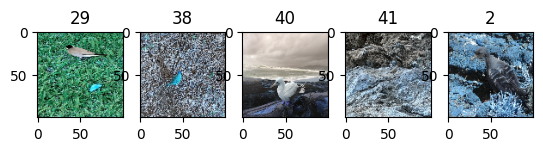

In [ ]:
import matplotlib.pyplot as plt

# Display the first few images and their corresponding labels
fig, axs = plt.subplots(1, 5)
for i in range(5):
    axs[i].imshow(train_images[i])
    print(train_images[i].shape)
    print(train_labels[i])
    axs[i].set_title(train_labels[i])
plt.show()

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

NameError: name 'torch' is not defined

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(640000 * 128, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        #x = torch.relu(self.fc2(x))
        x = self.fc2(x)
        return x

# Create a CNN model
model = CNN(num_classes)
model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    print(epoch)
    running_loss = 0.0
    model.train()
    running_loss = 0.0
    for data in train_loader:
        images, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader)}")



In [ ]:
import tensorflow
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalCrossentropy

In [ ]:
(train_images[0])

'[[[0.16862745 0.49803922 0.30196078]\n  [0.2        0.53333333 0.33333333]\n  [0.23529412 0.57254902 0.36470588]\n  ...\n  [0.35686275 0.63529412 0.50588235]\n  [0.20392157 0.4745098  0.34901961]\n  [0.05490196 0.30588235 0.18431373]]\n\n [[0.22352941 0.54509804 0.34117647]\n  [0.21960784 0.54117647 0.3372549 ]\n  [0.25098039 0.57647059 0.36862745]\n  ...\n  [0.2        0.49019608 0.34509804]\n  [0.19215686 0.47843137 0.33333333]\n  [0.18039216 0.46666667 0.31764706]]\n\n [[0.18431373 0.54117647 0.34509804]\n  [0.21176471 0.56862745 0.36862745]\n  [0.24705882 0.60392157 0.4       ]\n  ...\n  [0.24705882 0.5254902  0.37254902]\n  [0.10196078 0.34901961 0.20784314]\n  [0.01568627 0.22745098 0.09411765]]\n\n ...\n\n [[0.42745098 0.74117647 0.56470588]\n  [0.44705882 0.72941176 0.57254902]\n  [0.36862745 0.57647059 0.4627451 ]\n  ...\n  [0.18039216 0.52156863 0.35294118]\n  [0.10588235 0.42352941 0.25882353]\n  [0.01960784 0.31764706 0.15294118]]\n\n [[0.44705882 0.75294118 0.56862745]\n 

In [ ]:
model = Sequential()
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(100,100, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(66, (3, 3), activation='relu'))
model.add(Conv2D(66, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(300, activation='relu'))
model.add(Dense(43, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.00015),
            loss=CategoricalCrossentropy(),
            metrics=['accuracy'])
model.fit(x=train_images,
                y=train_labels,
                batch_size=50,
                epochs=20,
                validation_split=0.2,
                verbose=2,
                callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
              )

Epoch 1/20


ValueError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1150, in train_step
        y_pred = self(x, training=True)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/input_spec.py", line 253, in assert_input_compatibility
        raise ValueError(

    ValueError: Ex